wrote plot_iteration_knee.png
 k  qpu_s/iter  cpu_s/iter  E_total_kWh  cost/job  p95/median   CV  phi_qpu
 3       0.971       0.156       0.0534    0.0096        1.73 0.43   0.9843
 6       0.974       0.157       0.1070    0.0193        1.72 0.43   0.9840
 9       1.011       0.156       0.1665    0.0300        1.81 0.45   0.9851
12       1.413       0.155       0.3095    0.0557        2.87 0.72   0.9908
15       7.580       0.156       2.0573    0.3703        6.07 1.06   0.9987
18      25.994       0.156       8.4839    1.5271        6.02 1.08   0.9996
21      39.500       0.156      15.1589    2.7286        4.19 0.99   0.9997


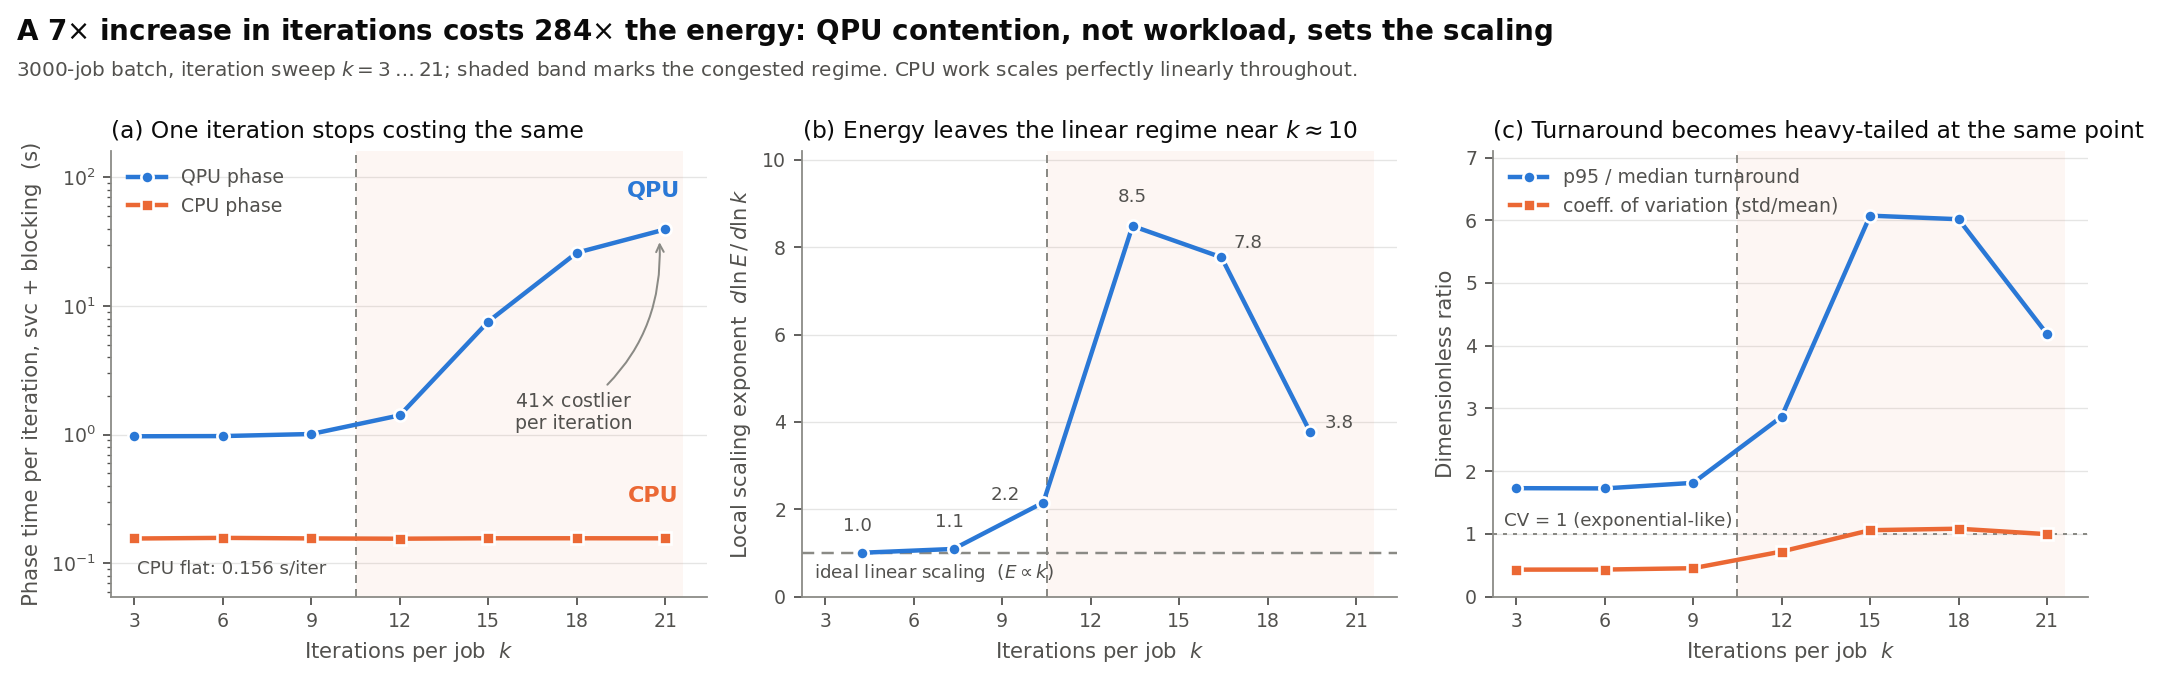

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

CSV = "iteration_sweep_summary-21.csv"
OUT = "plot_iteration_knee.png"

QPU = "#2a78d6"  # categorical slot 1
CPU = "#eb6834"  # categorical slot 2
INK = "#0b0b0b"
INK2 = "#52514e"
MUTED = "#8a8a85"
KNEE_FILL = "#eb6834"

plt.rcParams.update({
    "font.size": 9.5,
    "axes.titlesize": 10.5,
    "axes.labelsize": 9.5,
    "axes.edgecolor": MUTED,
    "axes.linewidth": 0.8,
    "axes.labelcolor": INK2,
    "xtick.color": INK2,
    "ytick.color": INK2,
    "xtick.labelsize": 8.5,
    "ytick.labelsize": 8.5,
    "legend.frameon": False,
    "figure.dpi": 160,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

d = pd.read_csv(CSV).sort_values("iterations").reset_index(drop=True)
k = d["iterations"].to_numpy(float)

qpu_per_it = d["mean_qpu_time_s"] / k
cpu_per_it = d["mean_cpu_time_s"] / k

# local log-log slope, evaluated at the geometric midpoint of each bracket
mid = np.sqrt(k[:-1] * k[1:])
slope_e = np.diff(np.log(d["mean_energy_total_kwh"])) / np.diff(np.log(k))

tail = d["p95_job_turnaround_s"] / d["median_job_turnaround_s"]
cv = d["std_job_turnaround_s"] / d["mean_job_turnaround_s"]

KNEE = 10.5  # midpoint of the 9 -> 12 bracket where the exponent leaves 1


def shade_knee(ax):
    ax.axvspan(KNEE, k.max() + 0.6, color=KNEE_FILL, alpha=0.055, lw=0)
    ax.axvline(KNEE, color=MUTED, lw=0.9, ls=(0, (4, 3)), zorder=1)


def tidy(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", color=MUTED, alpha=0.22, lw=0.6)
    ax.set_axisbelow(True)
    ax.set_xlim(2.2, 22.4)
    ax.set_xticks(k)
    ax.set_xlabel("Iterations per job  $k$")


fig, axes = plt.subplots(1, 3, figsize=(13.2, 4.3))

# ---- (a) marginal cost of one iteration -------------------------------------
ax = axes[0]
shade_knee(ax)
ax.plot(k, qpu_per_it, color=QPU, lw=2, marker="o", ms=5.5,
        mec="white", mew=1.2, label="QPU phase", zorder=3)
ax.plot(k, cpu_per_it, color=CPU, lw=2, marker="s", ms=5.5,
        mec="white", mew=1.2, label="CPU phase", zorder=3)
ax.set_yscale("log")
ax.set_ylim(0.055, 160)
# NOTE: the sweep's *_wait_s columns are identically 0, so blocking time is
# folded into the reported phase time -- label it honestly.
ax.set_ylabel("Phase time per iteration, svc + blocking  (s)")
ax.set_title("(a) One iteration stops costing the same", loc="left", color=INK)
ax.text(20.6, qpu_per_it.iloc[-1] * 1.8, "QPU", color=QPU, ha="center",
        fontweight="bold", fontsize=10)
ax.text(20.6, cpu_per_it.iloc[-1] * 1.9, "CPU", color=CPU, ha="center",
        fontweight="bold", fontsize=10)
ax.annotate(f"{qpu_per_it.iloc[-1] / qpu_per_it.iloc[0]:.0f}$\\times$ costlier\nper iteration",
            xy=(20.8, qpu_per_it.iloc[-1] * 0.86), xytext=(17.9, 1.1),
            color=INK2, fontsize=8.5, ha="center",
            arrowprops=dict(arrowstyle="->", color=MUTED, lw=0.9,
                            connectionstyle="arc3,rad=0.28"))
ax.text(3.1, 0.083, "CPU flat: 0.156 s/iter", color=INK2, fontsize=8.2)
ax.legend(loc="upper left", fontsize=8.5, labelcolor=INK2)
tidy(ax)

# ---- (b) local scaling exponent ---------------------------------------------
ax = axes[1]
shade_knee(ax)
ax.axhline(1.0, color=MUTED, lw=1.1, ls=(0, (5, 3)), zorder=2)
ax.text(2.6, 0.42, "ideal linear scaling  ($E \\propto k$)", color=INK2, fontsize=8.2)
ax.plot(mid, slope_e, color=QPU, lw=2, marker="o", ms=5.5,
        mec="white", mew=1.2, zorder=3)
label_off = [(-2, 10), (-2, 10), (-17, 1), (0, 11), (12, 4), (13, 2)]
for x, y, off in zip(mid, slope_e, label_off):
    ax.annotate(f"{y:.1f}", (x, y), textcoords="offset points",
                xytext=off, ha="center", fontsize=8.2, color=INK2)
ax.set_ylabel("Local scaling exponent  $d\\ln E\\,/\\,d\\ln k$")
ax.set_title("(b) Energy leaves the linear regime near $k\\approx10$",
             loc="left", color=INK)
ax.set_ylim(0, 10.2)
tidy(ax)

# ---- (c) predictability collapse --------------------------------------------
ax = axes[2]
shade_knee(ax)
ax.plot(k, tail, color=QPU, lw=2, marker="o", ms=5.5,
        mec="white", mew=1.2, label="p95 / median turnaround", zorder=3)
ax.plot(k, cv, color=CPU, lw=2, marker="s", ms=5.5,
        mec="white", mew=1.2, label="coeff. of variation (std/mean)", zorder=3)
ax.axhline(1.0, color=MUTED, lw=0.9, ls=(0, (2, 3)), zorder=2)
ax.text(2.6, 1.12, "CV = 1 (exponential-like)", color=INK2, fontsize=8.2)
ax.set_ylabel("Dimensionless ratio")
ax.set_title("(c) Turnaround becomes heavy-tailed at the same point",
             loc="left", color=INK)
ax.set_ylim(0, 7.1)
ax.legend(loc="upper left", fontsize=8.5, labelcolor=INK2)
tidy(ax)

fig.tight_layout(rect=(0, 0, 1, 0.86))
fig.text(0.008, 0.975,
         "A 7$\\times$ increase in iterations costs 284$\\times$ the energy: "
         "QPU contention, not workload, sets the scaling",
         ha="left", va="top", fontsize=12.5, color=INK, fontweight="bold")
fig.text(0.008, 0.912,
         "3000-job batch, iteration sweep $k=3\\dots21$; shaded band marks the "
         "congested regime. CPU work scales perfectly linearly throughout.",
         ha="left", va="top", fontsize=9, color=INK2)

fig.savefig(OUT)
print(f"wrote {OUT}")

# ---- console companion table ------------------------------------------------
tbl = pd.DataFrame({
    "k": k.astype(int),
    "qpu_s/iter": qpu_per_it.round(3),
    "cpu_s/iter": cpu_per_it.round(3),
    "E_total_kWh": d["mean_energy_total_kwh"].round(4),
    "cost/job": d["mean_cost_per_job"].round(4),
    "p95/median": tail.round(2),
    "CV": cv.round(2),
    "phi_qpu": d["mean_phi_qpu"].round(4),
})
print(tbl.to_string(index=False))
